To describe and better understand the PAROS dataset

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import io
import re
import math
import msoffcrypto
import re
import openpyxl

In [2]:
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box

In [3]:
# environment set up
from dotenv import load_dotenv
import os

# use os.getcwd instead of os.path.dirname(__file__) for jupyter notebooks to get the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

load_dotenv(os.path.join(parent_dir, ".env"))
pd.set_option("display.max_columns", None)

In [4]:
### Read the paros dataset
filename = "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"
# load password from .env
password = os.getenv("PAROS_PASSWORD")

with open("../../datasets/" + filename, "rb") as encrypted_data:
    paros = msoffcrypto.OfficeFile(encrypted_data)
    paros.load_key(password = password)
    # decrypt file into a BytesIO object
    decrypted = io.BytesIO()
    paros.decrypt(decrypted)

    # use pandas to read the decrypted Excel File
    df = pd.read_excel(decrypted)

/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


In [5]:
column_names = list(df.columns)
print(column_names)

['Case #', 'Country', 'City', 'Site #', 'Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Medical History - No', 'Medical History - Unknown', 'Medical History - Heart disease', 'Medical History - Diabetes', 'Medical History - Cancer', 'Medical History - Hypertension', 'Medical History - Renal Disease', 'Medical History - Respiratory Disease', 'Medical History - Hyperlipidemia', 'Medical History - Stroke', 'Medical History - HIV', 'Medical History - Other', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance left scene', 'Time Ambulance arrived at ED', 'Estimated time of arrest', 'Estimated time of arrest unknown', 'Arrest witnessed by', 'Bystander CPR', 'DA

Copying to a new dataframe, keeping only the columns of interest

In [6]:
columns_of_interest = ["Case #", "Site #", "Date of Incident", "Location of incident", 
                       "Location Unknown", "Location Type", "Location Type Other", "Age",
                       "Age Modifier", "Gender", "Race", "Time call received at dispatch center",
                       "Estimated time of arrest", "Estimated time of arrest unknown"]

df_of_interest = df[columns_of_interest].copy()
print(df_of_interest.head())

      Case #  Site # Date of Incident  Location of incident Location Unknown  \
0  SGSIN0213       2       2010-04-01              470146.0              NaN   
1  SGSIN0218       2       2010-04-01              520926.0              NaN   
2  SGSIN6480       6       2010-04-01              560565.0              NaN   
3  SGSIN5332       5       2010-04-02              680626.0              NaN   
4  SGSIN0214       2       2010-04-03              468963.0              NaN   

         Location Type          Location Type Other  Age Age Modifier  Gender  \
0       Home Residence                  HDB Level 7   60        Years    Male   
1       Home Residence                  HDB Level 2   60        Years  Female   
2  Healthcare Facility          NKF Dialysis Centre   64        Years    Male   
3       Home Residence                  HDB Level 7   48        Years  Female   
4  Place of Recreation  East Coast Park NSC Carpark   50        Years    Male   

      Race Time call received at

In [7]:
# convert to datetime format
df_of_interest["Date of Incident"] = pd.to_datetime(df["Date of Incident"], format = '%d/%m/%y')

# extract day of the week
df_of_interest["Day of Week"] = df_of_interest['Date of Incident'].dt.day_name()

# extract year
df_of_interest["Year"] = df_of_interest['Date of Incident'].dt.year

In [8]:
# OHCA count by year
year_count = df_of_interest.groupby(["Year"]).size().reset_index(name = "OHCA Count")
year_count

,Year,OHCA Count
0,2010,1081
1,2011,1377
2,2012,1440
3,2013,1736
4,2014,2038
5,2015,2372
6,2016,2505
7,2017,2841
8,2018,2975
9,2019,3233


Grouping by days of the week to observe the OHCA trend across the week

In [9]:
# group by day of week and count
day_counts = df_of_interest["Day of Week"].value_counts().sort_values()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(day_order).dropna()

print(day_counts)

Day of Week
Monday       4202
Tuesday      3943
Wednesday    3947
Thursday     4013
Friday       4127
Saturday     4288
Sunday       4145
Name: count, dtype: int64


Visualising it

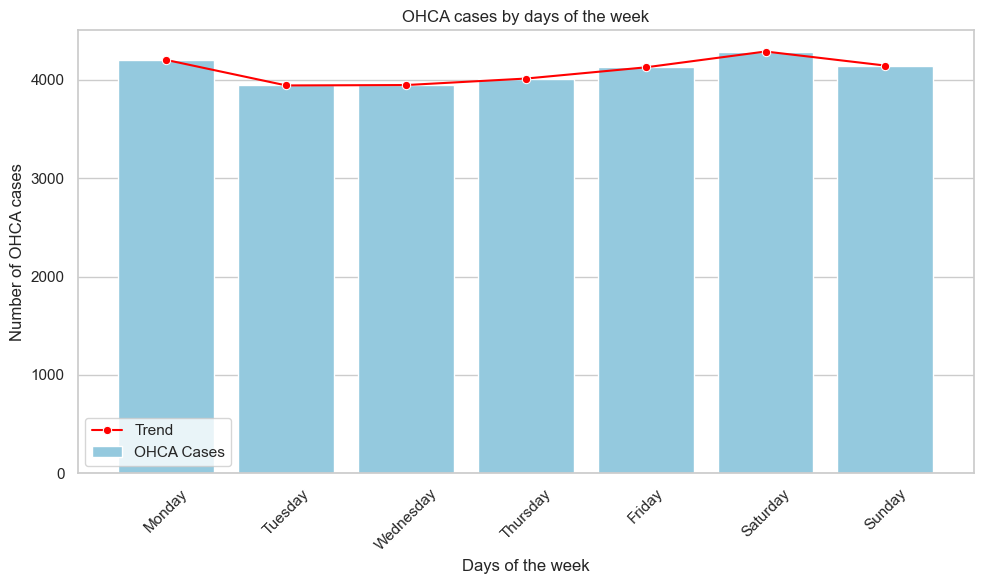

In [10]:
# Set the style
sns.set_theme(style="whitegrid")

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Plot bar chart (histogram)
sns.barplot(x=day_counts.index, y=day_counts.values, color='skyblue', label='OHCA Cases')

# Plot trend line
sns.lineplot(x=day_counts.index, y=day_counts.values, color='red', marker='o', label='Trend')

plt.xlabel("Days of the week")
plt.ylabel("Number of OHCA cases")
plt.title("OHCA cases by days of the week")
plt.xticks(rotation = 45)
plt.legend()

plt.tight_layout()
plt.show()


Spliting the OHCA count by year

In [11]:
# OHCA count for each day of the week each year under the "OHCA Count" column
day_year_group = df_of_interest.groupby(["Year", "Day of Week"]).size().reset_index(name = "OHCA Count")

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_year_group['Day of Week'] = pd.Categorical(day_year_group['Day of Week'], categories=day_order, ordered=True)
grouped = day_year_group.sort_values(['Year', 'Day of Week'])

print(grouped.head())

   Year Day of Week  OHCA Count
1  2010      Monday         146
5  2010     Tuesday         176
6  2010   Wednesday         133
4  2010    Thursday         166
0  2010      Friday         144


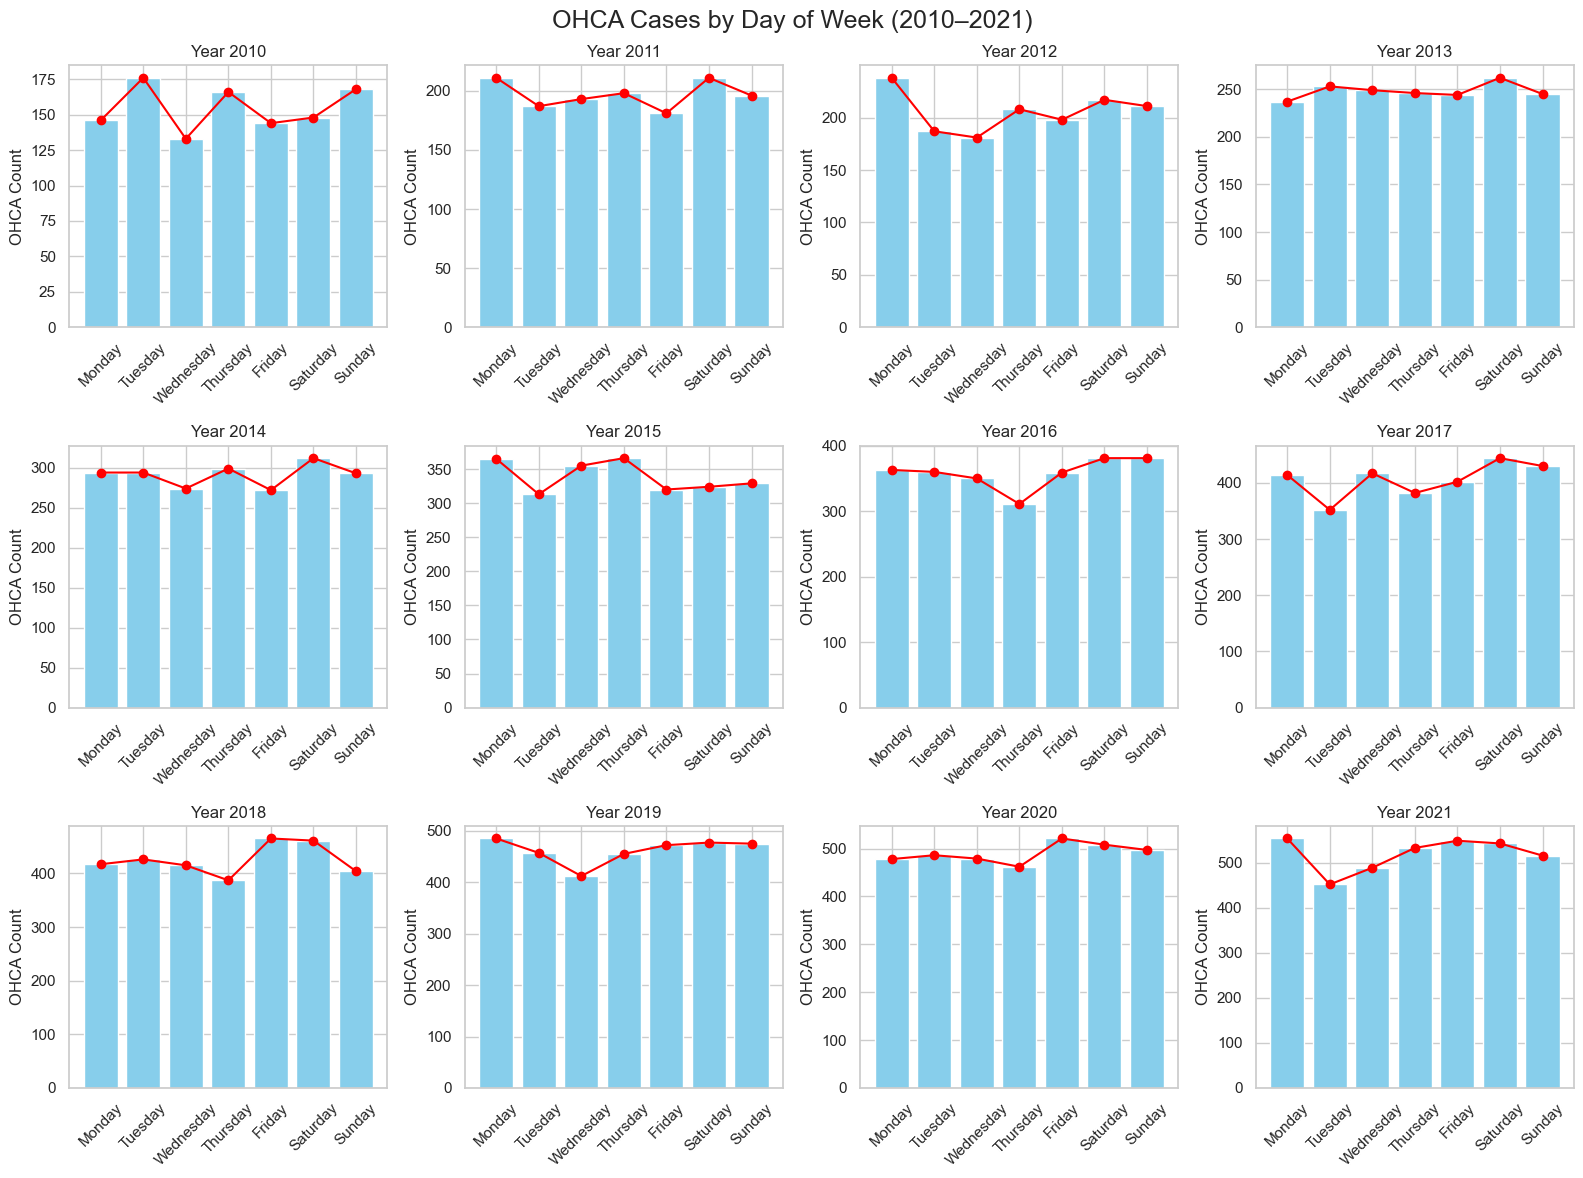

In [12]:
years = sorted(grouped["Year"].unique())

n_cols = 4
n_rows = (len(years) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize = (16, n_rows * 4), sharey = False)
axes = axes.flatten()

for i, year in enumerate(years):
    data = grouped[grouped["Year"] == year]
    # bar plot
    axes[i].bar(data['Day of Week'], data['OHCA Count'], color='skyblue')
    # trend line
    axes[i].plot(data['Day of Week'], data['OHCA Count'], color='red', marker='o',
                 linestyle='-', label='Trend')
    axes[i].set_title(f'Year {year}')
    axes[i].set_xticks(range(len(data['Day of Week'])))
    axes[i].set_xticklabels(data['Day of Week'], rotation=45)
    axes[i].set_ylabel('OHCA Count')

# remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('OHCA Cases by Day of Week (2010–2021)', fontsize=18)
plt.tight_layout()
plt.show()

There seems to be a trend where OHCA cases are generally lower on Tues, Wed and Thurs compared to the rest of the week.

2010's trend might be less accurate as the PAROS dataset started on April 2010

Now spliting the dataset by hours of the day

In [13]:
columns_of_interest = ["Estimated time of arrest", "Estimated time of arrest unknown", "Date of Incident"]
cases_by_hrs_df = df_of_interest[columns_of_interest].copy()

# remove whitespacing so that cases are not dropped due to formatting error.
cases_by_hrs_df["Estimated time of arrest"] = cases_by_hrs_df['Estimated time of arrest'].astype(str).str.strip()

# convert everything to date & time first
# because some of the estimated time is in datetime while most of them is time only. This is to standardise.
cases_by_hrs_df['Parsed Time'] = pd.to_datetime(cases_by_hrs_df['Estimated time of arrest'], errors='coerce', dayfirst=True)

# convert from datetime to hours
cases_by_hrs_df['Hour of Arrest'] = cases_by_hrs_df['Parsed Time'].dt.hour

total_missing = cases_by_hrs_df['Hour of Arrest'].isna().sum()
cases_by_hrs_df = cases_by_hrs_df.dropna(subset=["Hour of Arrest"])
print(f"Cases dropped due to no timing: {total_missing}")
# cases_by_hrs_df.to_excel("testing.xlsx")


Cases dropped due to no timing: 186


/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_34945/3989557187.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cases_by_hrs_df['Parsed Time'] = pd.to_datetime(cases_by_hrs_df['Estimated time of arrest'], errors='coerce', dayfirst=True)


Group by hour of arrest

In [14]:
cases_by_hour = cases_by_hrs_df["Hour of Arrest"].value_counts().sort_index()
# print(cases_by_hour)

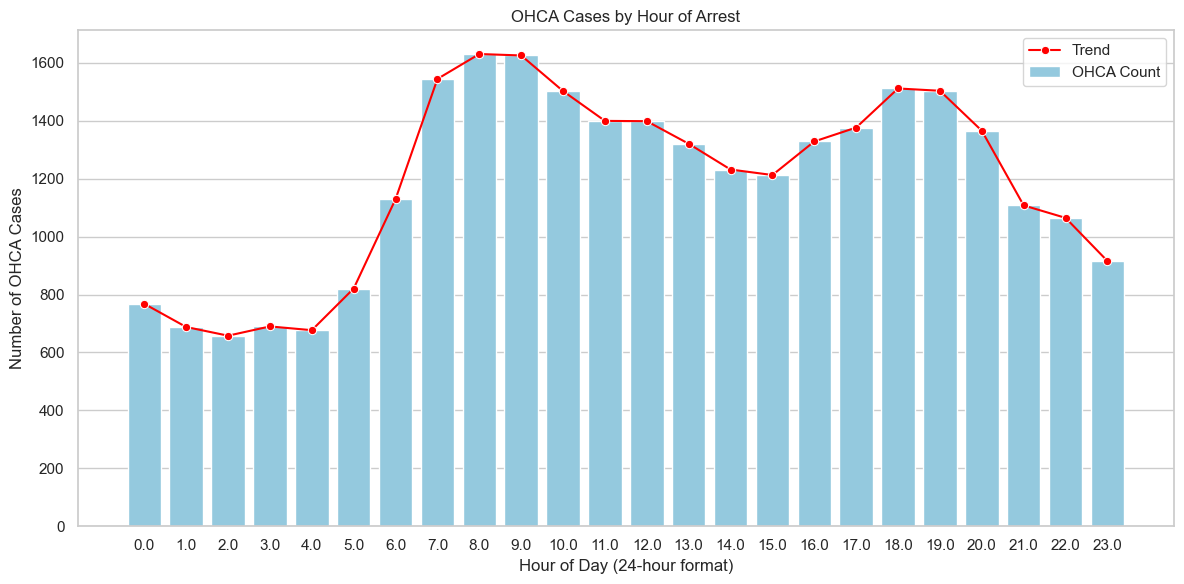

In [15]:
plt.figure(figsize = (12, 6))
sns.barplot(x = cases_by_hour.index, y = cases_by_hour.values, color='skyblue', label='OHCA Count')
sns.lineplot(x=cases_by_hour.index, y=cases_by_hour.values, color='red', marker='o', label='Trend')

plt.title('OHCA Cases by Hour of Arrest')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of OHCA Cases')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

Group by year

In [16]:
cases_by_hrs_df["Year"] = cases_by_hrs_df["Date of Incident"].dt.year

grouped_by_hour_year = cases_by_hrs_df.groupby(["Year", "Hour of Arrest"]).size().reset_index(name = "OHCA Count")

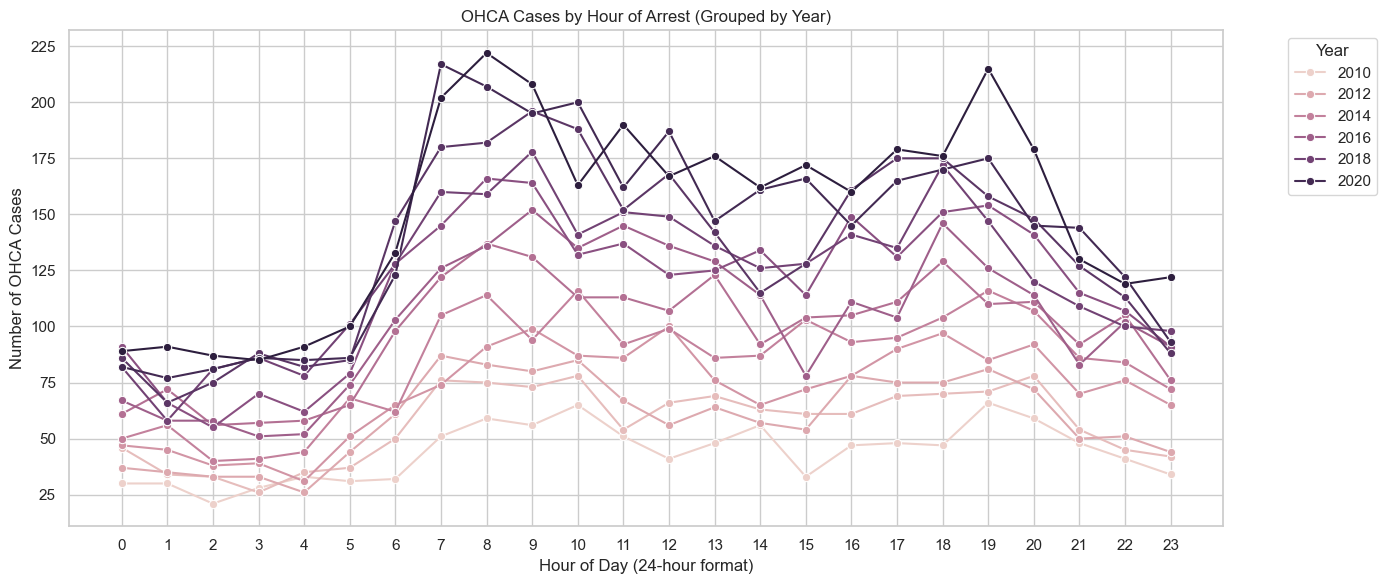

In [17]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=grouped_by_hour_year, x='Hour of Arrest', y='OHCA Count', hue='Year', marker='o')

plt.title('OHCA Cases by Hour of Arrest (Grouped by Year)')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of OHCA Cases')
plt.xticks(range(0, 24))
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Grouping OHCA cases by age group

- under 1

- 1 to 14

- 15 to 24

- 25 to 44

- 45 to 64

- 65=<

In [18]:
def convert_to_years(row):
    if row["Age Modifier"] == "Days":
        return row["Age"] / 365
    elif row["Age Modifier"] == "Months":
        return row["Age"] / 12
    # assume already in years
    else:
        return row["Age"]
    
df_of_interest['Age (Years)'] = df_of_interest.apply(convert_to_years, axis=1)

# numeric boundaries to split age into ranges
bins = [-0.01, 1, 15, 25, 45, 65, float('inf')]
# naming the ranges
labels = ['Under 1', '1–14', '15–24', '25–44', '45–64', '65+']

df_of_interest['Age Group'] = pd.cut(df_of_interest['Age (Years)'], bins=bins, labels=labels, right=False)

age_group_counts = df_of_interest["Age Group"].value_counts().reindex(labels)
print(df_of_interest[df_of_interest['Age Group'] == 'Under 1'][['Age', 'Age Modifier', 'Age (Years)']])

print(age_group_counts)

       Age Age Modifier  Age (Years)
39       0        Years          0.0
431      0        Years          0.0
449      0        Years          0.0
480      0        Years          0.0
599      0        Years          0.0
...    ...          ...          ...
27618    0        Years          0.0
28250    0         Days          0.0
28560    0        Years          0.0
28635    0        Years          0.0
28642    0        Years          0.0

[131 rows x 3 columns]
Age Group
Under 1      131
1–14         232
15–24        396
25–44       2242
45–64       8331
65+        17333
Name: count, dtype: int64


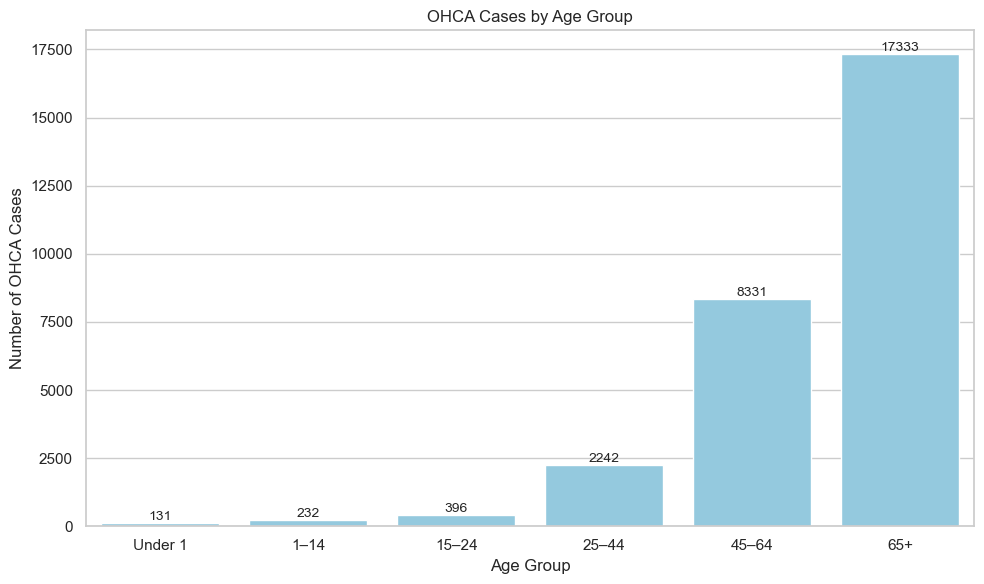

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, color='skyblue')

# Add labels on top of each bar
for i, value in enumerate(age_group_counts.values):
    plt.text(
        x=i,
        y=value + 1,  # Adjust if needed (e.g., value + 1 for spacing)
        s=str(int(value)),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('OHCA Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of OHCA Cases')
plt.tight_layout()
plt.show()

Group by age group and year

In [20]:
age_year_grouped = df_of_interest.groupby(['Year', 'Age Group'], observed=False).size().reset_index(name='OHCA Count')

age_year_pivot = age_year_grouped.pivot(index='Year', columns='Age Group', values='OHCA Count').fillna(0)
# print(age_year_pivot)

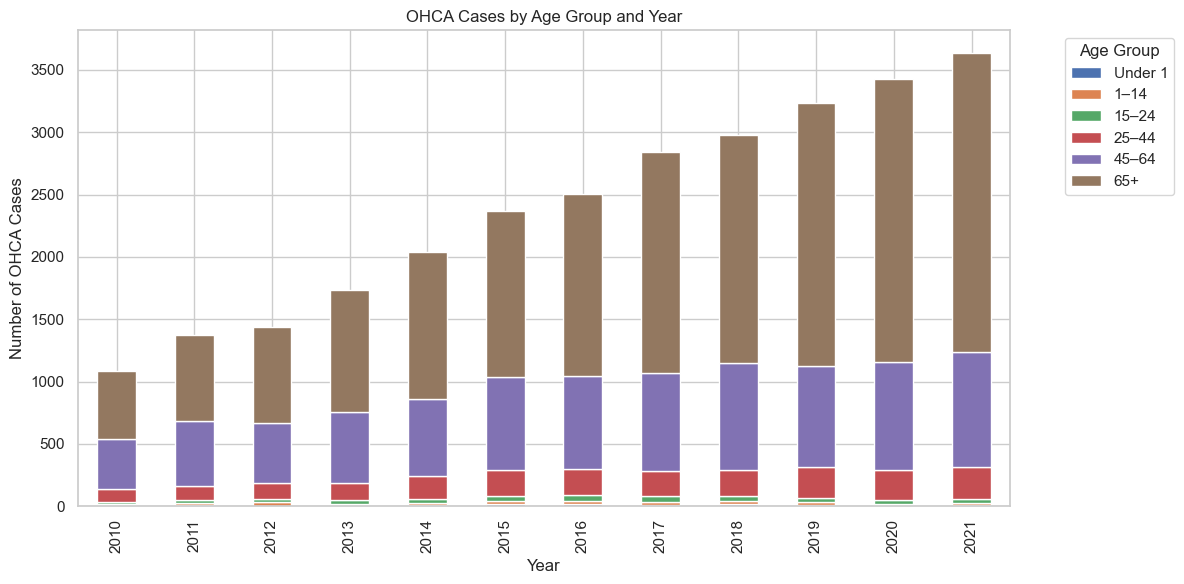

In [21]:
age_year_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('OHCA Cases by Age Group and Year')
plt.xlabel('Year')
plt.ylabel('Number of OHCA Cases')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Proportion of elderly (65+)

Elderly (65+) OHCA cases: 17333 / 28665 (60.5%)


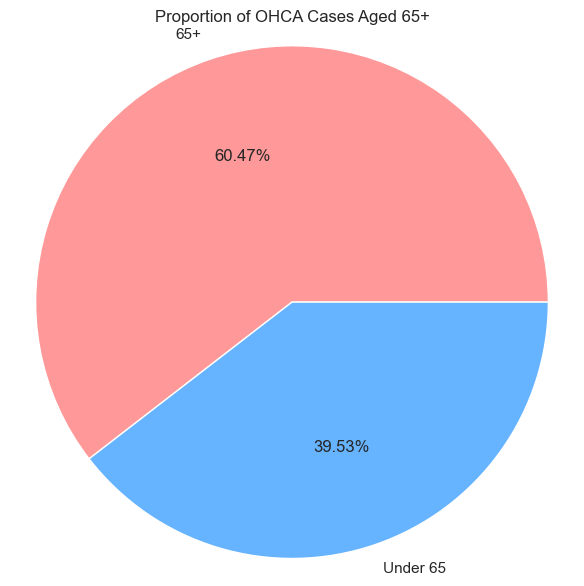

In [22]:
total_cases = df_of_interest['Age Group'].notna().sum()

# Number of elderly (65+) cases
elderly_cases = df_of_interest[df_of_interest['Age Group'] == '65+'].shape[0]

elderly_percentage = (elderly_cases / total_cases) * 100

print(f"Elderly (65+) OHCA cases: {elderly_cases} / {total_cases} ({elderly_percentage:.1f}%)")

labels = ['65+', 'Under 65']
sizes = [elderly_cases, total_cases - elderly_cases]
colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%.2f%%')
plt.title('Proportion of OHCA Cases Aged 65+')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

In [23]:
df_of_interest.columns

Index(['Case #', 'Site #', 'Date of Incident', 'Location of incident',
       'Location Unknown', 'Location Type', 'Location Type Other', 'Age',
       'Age Modifier', 'Gender', 'Race',
       'Time call received at dispatch center', 'Estimated time of arrest',
       'Estimated time of arrest unknown', 'Day of Week', 'Year',
       'Age (Years)', 'Age Group'],
      dtype='object')

Grouping OHCA cases by month

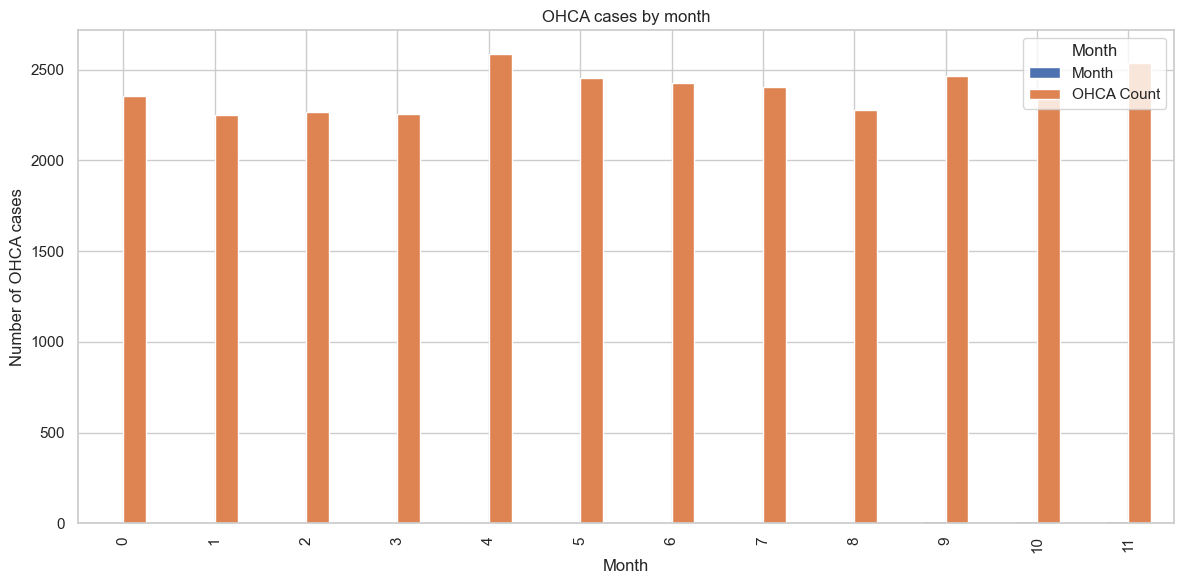

In [24]:
df_of_interest["Month"] = df_of_interest["Date of Incident"].dt.month

month_grouped = df_of_interest.groupby(["Month"]).size().reset_index(name = "OHCA Count")

month_grouped.plot(kind = "bar", figsize = (12, 6))
plt.title("OHCA cases by month")
plt.xlabel("Month")
plt.ylabel("Number of OHCA cases")
plt.legend(title = "Month", loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
month_year_grouped = df_of_interest.groupby(["Month", "Year"]).size().reset_index(name = "OHCA Count")

month_year_pivot = month_year_grouped.pivot(index='Year', columns='Month', values='OHCA Count').fillna(0)
# month_year_pivot

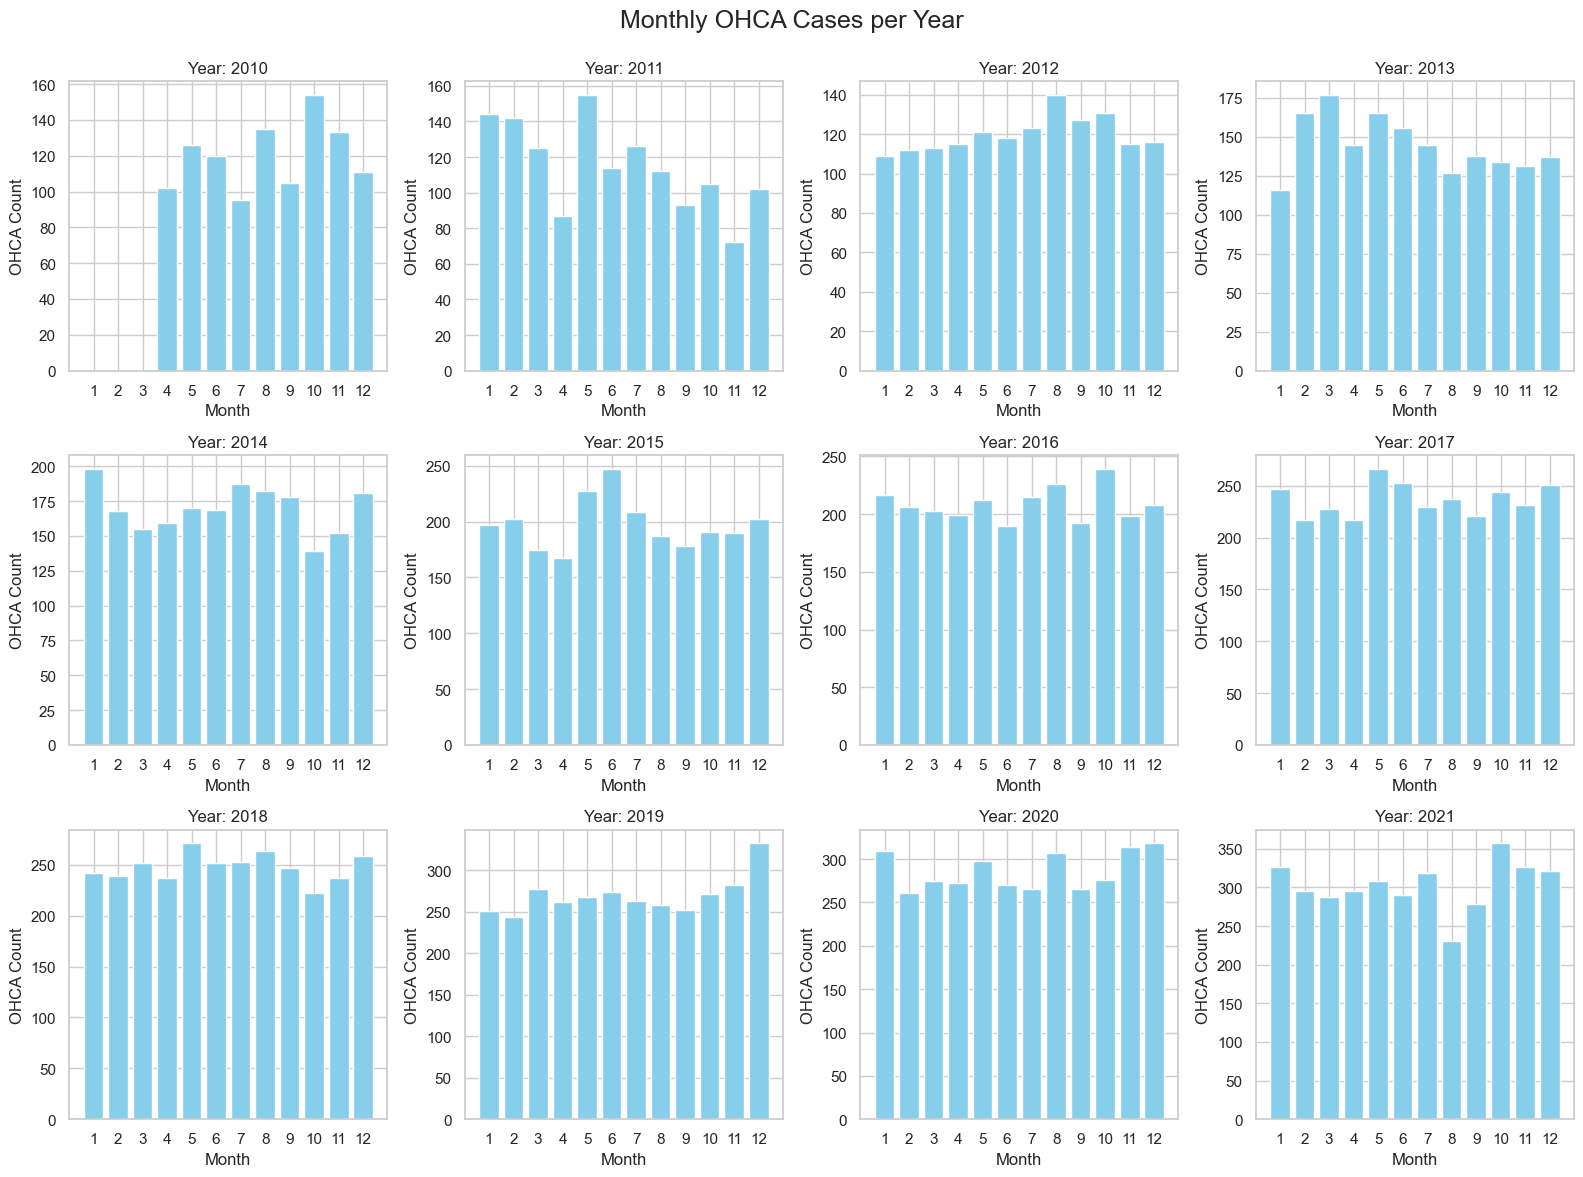

In [26]:
years = month_year_pivot.index
n_cols = 4
n_rows = (len(years) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4), sharey=False)
axes = axes.flatten()

# Plot one graph per year
for i, year in enumerate(years):
    month_counts = month_year_pivot.loc[year]
    axes[i].bar(month_counts.index, month_counts.values, color='skyblue')
    axes[i].set_title(f'Year: {year}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('OHCA Count')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(range(1, 13))

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Monthly OHCA Cases per Year', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

Proportion of male that experienced OHCA

   Gender  OHCA Count  Percentage
0  Female       10376        36.2
1    Male       18289        63.8


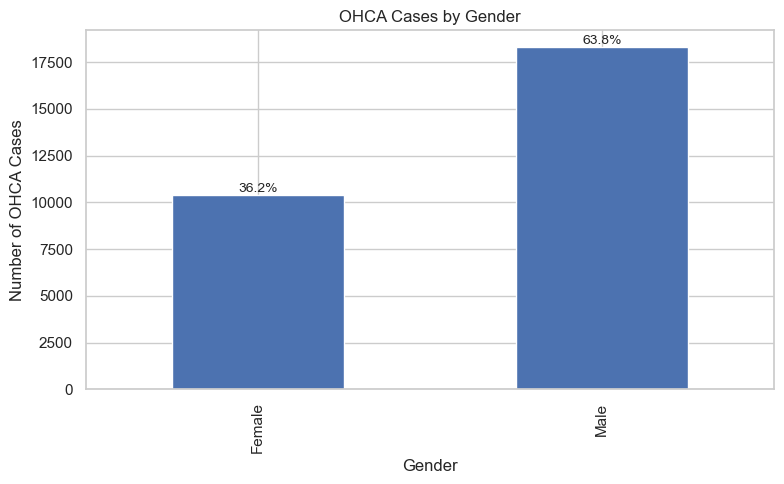

In [29]:
cases_by_gender = df_of_interest.groupby(["Gender"]).size().reset_index(name = "OHCA Count")
total_cases = cases_by_gender["OHCA Count"].sum()
cases_by_gender["Percentage"] = (cases_by_gender["OHCA Count"] / total_cases * 100).round(1)

ax = cases_by_gender.set_index("Gender")["OHCA Count"].plot(
    kind = "bar",
    figsize = (8, 5))
print(cases_by_gender)

for i, (count, pct) in enumerate(zip(cases_by_gender['OHCA Count'], cases_by_gender['Percentage'])):
    plt.text(i, count + 1, f'{pct}%', ha='center', va='bottom', fontsize=10)

plt.title('OHCA Cases by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of OHCA Cases')
plt.tight_layout()
plt.show()